#Implement an End to End CNN Model for Image Classification Task

#Mounting Drive and unzipping the zipped file

In [75]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile #For handling zipped files
import os #For navigating folders

zip_path = '/content/drive/MyDrive/AI_ML/FruitinAmazon.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset') #Extract ALL contents to /content/dataset folder


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Path to the training and test dataset

In [76]:
#paths to training and testing data directories
train_dir = '/content/dataset/FruitinAmazon/train'
test_dir  = '/content/dataset/FruitinAmazon/test'

In [77]:
#Import all required libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

##Task 1: Data Understanding and Visualization:

### Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

Classes found: ['graviola', 'guarana', 'acai', 'tucuma', 'pupunha', 'cupuacu']
Observation: Each class contains images of different Amazon fruits with varying sizes, backgrounds, and lighting conditions.


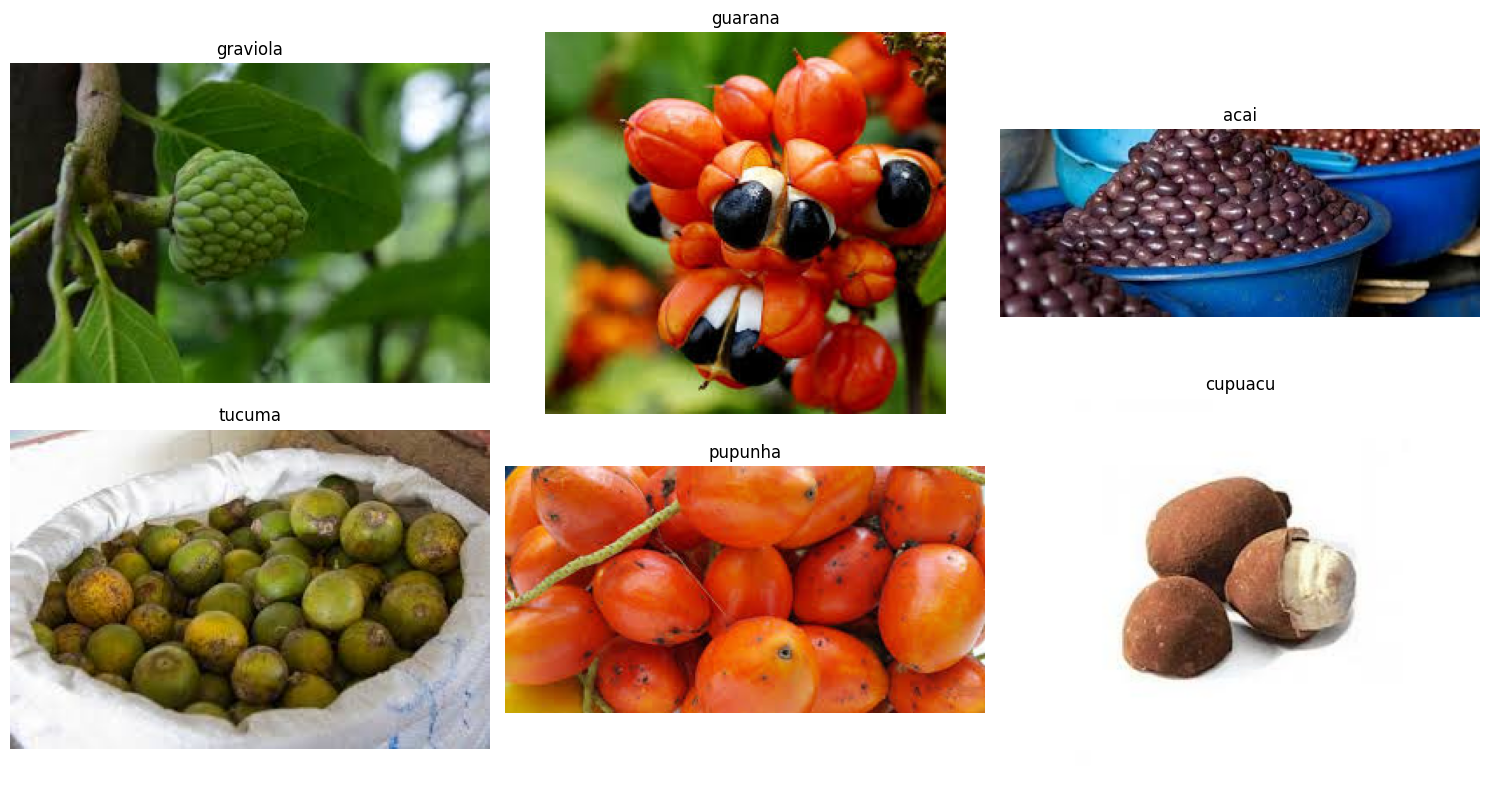

In [78]:
# List of all fruit class folder names from the train directoryclasses = os.listdir(train_dir)
print(f"Classes found: {classes}")

# Select one random image per class and display in 2-row grid
num_classes = len(classes)
cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(15, 8))
axes = axes.flatten() # Flatten 2D grid to 1D for easy indexing

# Loop through each class and display one random image
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls) # Full path to class folder
    images = os.listdir(cls_path) # List all images in that folder
    random_img = random.choice(images) # Pick one image at random
    img_path = os.path.join(cls_path, random_img)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

# Hide any leftover empty subplots if classes don't fill the grid perfectly
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
print("Observation: Each class contains images of different Amazon fruits with varying sizes, backgrounds, and lighting conditions.")

### Check for Corrupted Image:

In [79]:
#Corrupted Image Check

corrupted = []   # List to track any corrupted image paths

# Loop through every image in every class folder
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)        # Path to class folder
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)  # Full path to image
        try:
            img = Image.open(img_path)   # Try to open the image
            img.verify()                 # Verify it is not corrupted
                                         # verify() checks file integrity without fully loading
        except (IOError, SyntaxError):
            # IOError    → file cannot be read (missing/broken)
            # SyntaxError → file is not a valid image format
            print(f"Removed corrupted image: {img_path}")
            os.remove(img_path)          # Delete the corrupted file
            corrupted.append(img_path)   # Record it in the list

# Report result
if not corrupted:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


## Task 2: Loading and Preprocessing Image Data in keras:

In [80]:
import tensorflow as tf

# Hyperparameters
img_height = 128
img_width  = 128
batch_size = 16
validation_split = 0.2
SEED = 123


In [81]:
# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

In [82]:
# Training dataset (80%)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed= SEED
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [83]:
# Validation dataset (20%)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed= SEED
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [84]:
# Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [85]:
# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = test_ds.map(lambda x, y: (rescale(x), y))

In [86]:
# Get class names and count
class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else os.listdir(train_dir)
# Count number of classes by counting subfolders in train directory
num_classes = len(os.listdir(train_dir))
print(f"Number of classes: {num_classes}")
print(f"Class names: {os.listdir(train_dir)}")

Number of classes: 6
Class names: ['graviola', 'guarana', 'acai', 'tucuma', 'pupunha', 'cupuacu']


## Task 3 - Implement a CNN




In [87]:
# ─── Task 3: Build the CNN Model ───

model = keras.Sequential([

    # Define input shape: image height x width x 3 colour channels (RGB)
    layers.Input(shape=(img_height, img_width, 3)),

    # ── First Convolutional Block ──
    # 32 filters of size 3x3, stride 1, same padding keeps output same size as input
    # ReLU activation introduces non-linearity — helps detect edges and simple patterns
    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),

    # Max pooling reduces spatial dimensions by half (2x2 window, stride 2)
    # Keeps the most prominent features while reducing computation
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Second Convolutional Block ──
    # Another 32 filters — learns more complex patterns from the pooled feature maps
    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),

    # Second max pooling — further reduces spatial size
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Fully Connected Section ──
    # Flatten converts the 2D feature maps into a 1D vector
    # so it can be fed into Dense layers
    layers.Flatten(),

    # First dense hidden layer with 64 neurons and ReLU activation
    layers.Dense(64, activation="relu"),

    # Second dense hidden layer with 128 neurons — learns higher level combinations
    layers.Dense(128, activation="relu"),

    # Output layer — one neuron per class
    # Softmax converts raw scores into probabilities that sum to 1
    layers.Dense(num_classes, activation="softmax")
])

# Print a summary of all layers, output shapes, and parameter counts
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile the Model

In [88]:
model.compile(
    optimizer='adam', # Adam optimizer — adapts learning rate automatically
    loss='sparse_categorical_crossentropy', # Loss function for integer class labels (not one-hot)
    metrics=['accuracy'] # Track accuracy during training and validation
)

## Save best model during training

In [89]:
# ModelCheckpoint — saves the model automatically whenever val_accuracy improves
checkpoint_cb = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
# EarlyStopping — stops training if val_accuracy doesn't improve for 15 epochs
earlystop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

## Task 4: Train the Model

In [90]:
history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.2056 - loss: 2.6946
Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 496ms/step - accuracy: 0.1528 - loss: 2.6765 - val_accuracy: 0.2222 - val_loss: 1.5685
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.2271 - loss: 1.7991
Epoch 2: val_accuracy did not improve from 0.22222
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 628ms/step - accuracy: 0.2500 - loss: 1.7750 - val_accuracy: 0.2222 - val_loss: 1.6160
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.3493 - loss: 1.7006
Epoch 3: val_accuracy did not improve from 0.22222
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 562ms/step - accuracy: 0.3611 - loss: 1.6870 - val_accuracy: 0.2222 - val_loss: 1.7294
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.6306 - loss: 1.5841
Epoch 4: val_accuracy did not improve from 0.22222
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 499ms/step - accuracy: 0.6528 - loss: 1.5552 - val_accuracy: 0.1667 - val_loss: 1.7032
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.7378 - loss: 1.308


Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6806 - loss: 0.9710 - val_accuracy: 0.4444 - val_loss: 1.4849
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.7493 - loss: 0.7998
Epoch 7: val_accuracy improved from 0.44444 to 0.72222, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 596ms/step - accuracy: 0.7361 - loss: 0.8387 - val_accuracy: 0.7222 - val_loss: 0.9496
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9233 - loss: 0.5942
Epoch 8: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.8611 - loss: 0.6693 - val_accuracy: 0.5556 - val_loss: 0.8861
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9597 - loss: 0.3826
Epoch 9: val_accuracy improved from 0.72222 to 0.77778, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.9444 - loss: 0.3683 - val_accuracy: 0.7778 - val_loss: 0.6222
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 1.0000 - loss: 0.2601
Epoch 10: val_accuracy improved from 0.77778 to 0.83333, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 1.0000 - loss: 0.2406 - val_accuracy: 0.8333 - val_loss: 0.5869
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9778 - loss: 0.1788
Epoch 11: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 0.9722 - loss: 0.1605 - val_accuracy: 0.8333 - val_loss: 0.5285
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9941 - loss: 0.0595
Epoch 12: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step - accuracy: 0.9861 - loss: 0.0708 - val_accuracy: 0.8889 - val_loss: 0.3929
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9799 - loss: 0.0686
Epoch 13: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 493ms/step - accuracy: 0.9722 - loss: 0.0836 - val_accuracy: 0.8889 - val_loss: 0.4477
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9837 - loss: 0.0843
Epoch 14: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 539ms/step - accuracy: 0.9861 - loss: 0.0668 - val_accuracy: 0.6667 - val_loss: 0.6567
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.9222 - loss: 0.1358
Epoch 15: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 292ms/step - accuracy: 0.9444 - loss: 0.1021 - val_accuracy: 0.8333 - val_loss: 0.5197
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9712 - los

# Task 5: Evaluate the Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6000 - loss: 1.1075

Test Accuracy: 0.6000
Test Loss:     1.1075


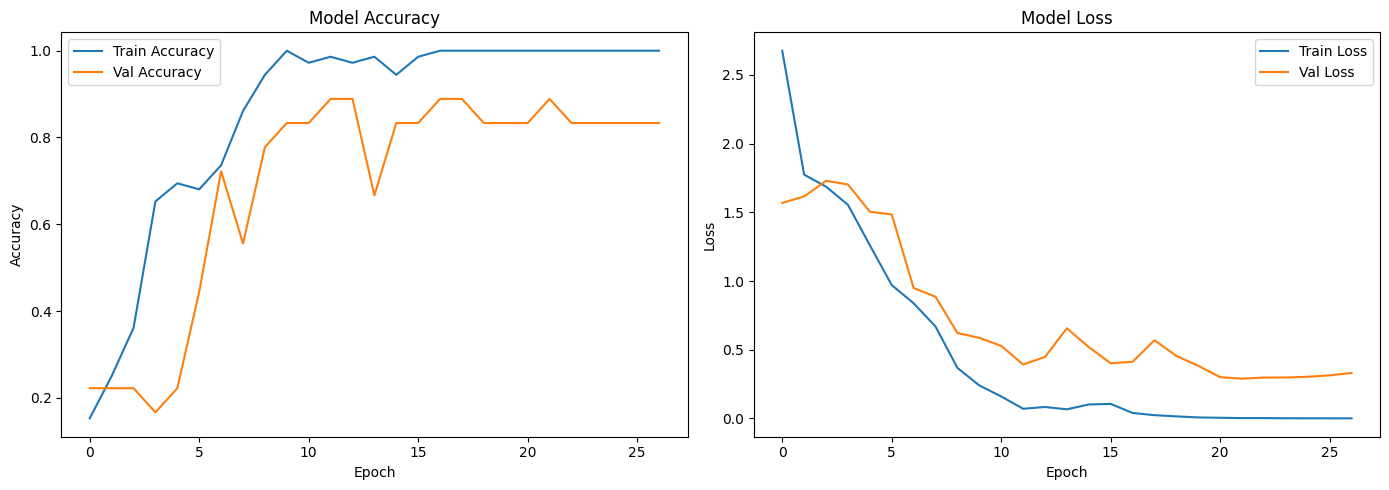

In [91]:
# Returns test loss and test accuracy
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Shows how train and validation accuracy changed across epochs
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Shows how train and validation loss changed across epochs
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()


## Task 6: Save and Load the Model

In [92]:
# Save the Trained Model
model.save('fruit_cnn_model.h5')
print("Model saved as fruit_cnn_model.h5")

# Load the saved model back from disk
loaded_model = tf.keras.models.load_model('fruit_cnn_model.h5')
# Re-evaluate the loaded model on the test set
loss, acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model - Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")

Model saved as fruit_cnn_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.6000 - loss: 1.1075
Loaded Model - Test Accuracy: 0.6000 | Test Loss: 1.1075


## Task 7: Predictions and Classification Report

In [93]:
# Collect Predictions from the Loaded Model

y_true = []   # List to store true labels from the test dataset
y_pred = []   # List to store predicted labels from the model

# Loop through each batch in the test dataset
for images, labels in test_ds:

    # Run the loaded model on this batch of images
    # Returns probability distribution across all classes for each image
    predictions = loaded_model.predict(images, verbose=0)

    # Convert probabilities to class index by taking the highest probability
    # e.g. [0.1, 0.7, 0.2] → class 1
    predicted_labels = np.argmax(predictions, axis=1)

    # Store the true labels and predicted labels for this batch
    y_true.extend(labels.numpy())      # .numpy() converts tensor to regular array
    y_pred.extend(predicted_labels)

# Convert both lists to numpy arrays for use with sklearn
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [94]:
# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

    graviola       0.44      0.80      0.57         5
     guarana       0.57      0.80      0.67         5
        acai       0.67      0.40      0.50         5
      tucuma       0.57      0.80      0.67         5
     pupunha       1.00      0.40      0.57         5
     cupuacu       1.00      0.40      0.57         5

    accuracy                           0.60        30
   macro avg       0.71      0.60      0.59        30
weighted avg       0.71      0.60      0.59        30

